# Big idea 1: three ways to find a law of nature
**White box, black box, gray box.** How did scientists find rules in the past, how does machine learning
find them today, and why the most exciting work mixes the two.

> 🐍 **How to use this notebook:** run the cells from top to bottom and read the story.
> The code uses NumPy, plots and scikit-learn, which you will learn in Lectures 9 and 10.
> You do not need to understand every line today: read the comments and look at the results.

> 🚀 **Going further** is optional: not in the homework, not on the exam. It is for students who
> finished the lecture notebooks and want to see more. Everything here runs in Colab, nothing to install.

## The question
Pip's café has an old **pendulum clock**. One swing takes a time **T** (seconds), and it depends on the
length **L** of the pendulum (meters). We want a rule: *give me L, I tell you T*.

There are three ways to get that rule:

| | Who finds the rule? | Can you read the rule? |
|---|---|---|
| ⬜ **White box** | A human, using physics | Yes, it is a formula |
| ⬛ **Black box** | The computer, from examples (machine learning) | No, it is thousands of numbers |
| 🔲 **Gray box** | The computer, from examples, **but** it must answer with a formula | Yes |

For 400 years science was mostly white box. Machine learning made black box easy.
Gray box takes the best of both.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

rng = np.random.default_rng(7)   # fixed seed: same numbers every run

## Step 0: the lab measurements
A student measured 30 pendulums between 0.2 m and 2 m with a stopwatch. A stopwatch is not perfect,
so every time has a small error (about 0.03 s).
*(The data is synthetic: made by the computer, with the same kind of error a real stopwatch makes.)*

   length_m  swing_time_s
0      0.21         0.872
1      0.26         1.017
2      0.28         1.030
3      0.49         1.378
4      0.59         1.570


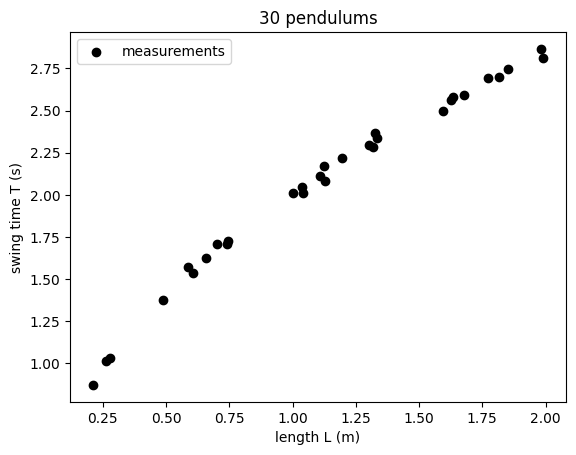

In [2]:
g = 9.81                                   # gravity on Earth, m/s^2
length = np.sort(rng.uniform(0.2, 2.0, 30))   # 30 lengths in meters
true_time = 2 * np.pi * np.sqrt(length / g)
swing_time = true_time + rng.normal(0, 0.03, 30)   # stopwatch error

lab = pd.DataFrame({"length_m": length.round(2), "swing_time_s": swing_time.round(3)})
print(lab.head())

plt.scatter(length, swing_time, color="black", label="measurements")
plt.xlabel("length L (m)")
plt.ylabel("swing time T (s)")
plt.title("30 pendulums")
plt.legend()
plt.show()

## ⬜ Way 1: white box (the classic way)
Galileo and Huygens worked it out with physics more than 350 years ago:

$$T = 2\pi \sqrt{\frac{L}{g}}$$

No data needed to *write* it. We only check it against the data.

In [3]:
def white_box(L, g=9.81):
    return 2 * np.pi * np.sqrt(L / g)

error = np.sqrt(np.mean((white_box(length) - swing_time) ** 2))
print(f"Typical error: {error:.3f} s   (the stopwatch error is 0.03 s)")
print(f"A 10 m pendulum: {white_box(10):.2f} s")
print(f"A 1 m pendulum on the Moon (g = 1.62): {white_box(1, g=1.62):.2f} s")

Typical error: 0.027 s   (the stopwatch error is 0.03 s)
A 10 m pendulum: 6.34 s
A 1 m pendulum on the Moon (g = 1.62): 4.94 s


✅ Works everywhere, even far outside the data and even on the Moon. You can read it and explain it.
❌ Someone had to discover the physics. For many problems (traffic, prices, the weather in detail, your
handwriting) nobody can write a formula.

## ⬛ Way 2: black box (machine learning)
Now forget the physics. We give the computer only the 30 examples and say: *learn the rule yourself*.
We try two learners you will meet in Lecture 10: a **forest** of decision trees and a small **neural network**.

In [4]:
X = length.reshape(-1, 1)   # scikit-learn wants a table with one column

forest = RandomForestRegressor(n_estimators=200, random_state=7).fit(X, swing_time)
network = MLPRegressor(hidden_layer_sizes=(20, 20), max_iter=20000, random_state=7).fit(X, swing_time)

for name, model in [("forest", forest), ("network", network)]:
    error = np.sqrt(np.mean((model.predict(X) - swing_time) ** 2))
    print(f"{name:8} typical error on the lab data: {error:.3f} s")

forest   typical error on the lab data: 0.021 s
network  typical error on the lab data: 0.032 s


Both learned the rule **without any physics**, and both are about as good as the formula on the data
they saw. (The forest is even "better" than the formula: it learned the stopwatch mistakes by heart.
That is called **overfitting**.)

But now ask about pendulums nobody measured:

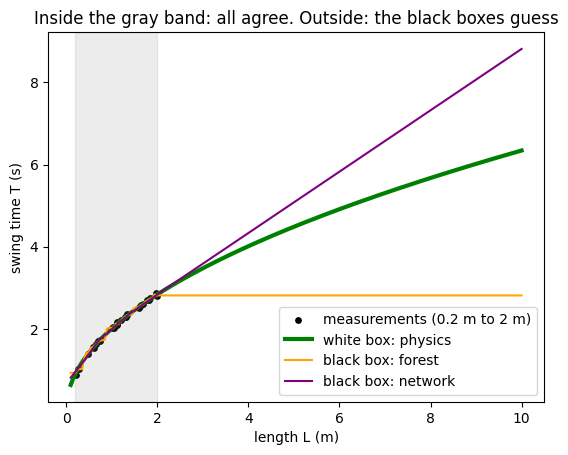

L =  1 m   physics 2.01 s   forest 2.02 s   network 1.99 s
L =  5 m   physics 4.49 s   forest 2.81 s   network 5.08 s
L = 10 m   physics 6.34 s   forest 2.81 s   network 8.82 s


In [5]:
grid = np.linspace(0.1, 10, 200).reshape(-1, 1)
plt.scatter(length, swing_time, color="black", s=15, label="measurements (0.2 m to 2 m)")
plt.plot(grid, white_box(grid), color="green", lw=3, label="white box: physics")
plt.plot(grid, forest.predict(grid), color="orange", label="black box: forest")
plt.plot(grid, network.predict(grid), color="purple", label="black box: network")
plt.axvspan(0.2, 2.0, color="gray", alpha=0.15)
plt.xlabel("length L (m)")
plt.ylabel("swing time T (s)")
plt.title("Inside the gray band: all agree. Outside: the black boxes guess")
plt.legend()
plt.show()

for L in [1, 5, 10]:
    print(f"L = {L:2} m   physics {white_box(L):.2f} s   forest {forest.predict([[L]])[0]:.2f} s   network {network.predict([[L]])[0]:.2f} s")

❌ **Outside the data, a black box is guessing.** The forest can only repeat answers it has seen, so a
10 m pendulum gets the same time as a 2 m one. The network keeps drawing a line in roughly the same direction.

❌ **You cannot read it.** Let's look inside the network:

In [6]:
knobs = sum(w.size for w in network.coefs_) + sum(b.size for b in network.intercepts_)
print(f"The network is {knobs} numbers. Here are the first 5:")
print(network.coefs_[0][0][:5].round(3))
print("Which one is gravity? None of them. You cannot ask it about the Moon.")

The network is 481 numbers. Here are the first 5:
[-0.325  0.253 -0.003  0.309  0.582]
Which one is gravity? None of them. You cannot ask it about the Moon.


✅ But: it needed **no physics at all**. That is why black boxes win where nobody has a formula:
recognizing faces, translating languages, recommending songs, predicting traffic.

## 🔲 Way 3: gray box (both)
**Gray box, flavor A: we know the shape, the data gives the number.**
Physics tells us *T grows like √L*. We let the data find the one missing number `a` in `T = a·√L`,
then turn it back into gravity: `g = (2π / a)²`.

In [7]:
a = np.sum(swing_time * np.sqrt(length)) / np.sum(length)   # best a (least squares)
measured_g = (2 * np.pi / a) ** 2
print(f"best a = {a:.3f}")
print(f"gravity measured from 30 stopwatch times: g = {measured_g:.2f} m/s^2   (real: 9.81)")

best a = 2.008
gravity measured from 30 stopwatch times: g = 9.79 m/s^2   (real: 9.81)


From a stopwatch and a string, we **measured gravity**. The model is readable, has one knob that means
something (`g`), and works on the Moon too.

**Gray box, flavor B: symbolic regression. We do not even know the shape.**
Let the computer *search for the formula itself*. We give it building blocks (powers of L, log, exp, sin),
it tries every formula `T = a · block`, picks the best `a` for each, and ranks them by error.

In [8]:
def formula_search(x, y, name="x"):
    blocks = {}
    for p in np.arange(-2, 3.01, 0.25):          # powers: x^-2, x^-1.75, ..., x^3
        blocks[f"{name}^{p:g}"] = x ** p
    blocks[f"log({name})"] = np.log(x)
    blocks[f"exp({name})"] = np.exp(x)
    blocks[f"sin({name})"] = np.sin(x)

    rows = []
    for formula, f in blocks.items():
        a = np.sum(y * f) / np.sum(f * f)        # best number in front
        error = np.sqrt(np.mean((a * f - y) ** 2))
        rows.append({"formula": f"{a:.3f} * {formula}", "error": round(error, 4)})
    return pd.DataFrame(rows).sort_values("error").head(5).reset_index(drop=True)

print(f"Tried {len(np.arange(-2, 3.01, 0.25)) + 3} formulas. Best 5:")
formula_search(length, swing_time, "L")

Tried 24 formulas. Best 5:


,formula,error
0,2.008 * L^0.5,0.0267
1,1.862 * L^0.75,0.2030
2,2.581 * sin(L),0.2149
3,2.093 * L^0.25,0.2576
4,1.686 * L^1,0.3800


🎉 The winner is `2.008 * L^0.5`, that is **T = 2.008·√L**, and 2π/√9.81 = 2.006. The computer
**rediscovered the pendulum law** from 30 noisy measurements, and gave it back as a formula we can read.

Real symbolic-regression tools (for example **PySR** and **AI Feynman**) do the same with millions of
formulas built from `+ − × ÷`, powers, `sin`, `exp`... In 2020 AI Feynman rediscovered all 100 equations
it was tested on from the *Feynman Lectures on Physics*, from data alone.

## 🪐 Now with real data: Kepler's third law
Around 1600 Johannes Kepler got Tycho Brahe's planet observations. After years of calculating by hand he
published (1619) that a planet's year **P** depends on its distance from the Sun **a**.
Here are the real values (NASA planetary fact sheet: distance in AU, where Earth = 1, period in Earth years).

In [9]:
planets = pd.DataFrame({
    "planet":   ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"],
    "distance": [0.387, 0.723, 1.000, 1.524, 5.203, 9.537, 19.19, 30.07],
    "year":     [0.241, 0.615, 1.000, 1.881, 11.86, 29.46, 84.01, 164.8],
})
print(planets)
formula_search(planets["distance"].values, planets["year"].values, "a")

    planet  distance     year
0  Mercury     0.387    0.241
1    Venus     0.723    0.615
2    Earth     1.000    1.000
3     Mars     1.524    1.881
4  Jupiter     5.203   11.860
5   Saturn     9.537   29.460
6   Uranus    19.190   84.010
7  Neptune    30.070  164.800


,formula,error
0,0.999 * a^1.5,0.0090
1,0.438 * a^1.75,4.0393
2,2.251 * a^1.25,4.8627
3,0.190 * a^2,7.4380
4,0.082 * a^2.25,10.3360


**`P = 1.0 · a^1.5`**, that is **P² = a³**: Kepler's third law, found in under a second.

And the black box? Train a forest on the six planets Kepler knew (Mercury to Saturn), then ask about
Uranus and Neptune, discovered later:

In [10]:
known = planets.iloc[:6]
forest_planets = RandomForestRegressor(n_estimators=200, random_state=7)
forest_planets.fit(known[["distance"]], known["year"])

new = planets.iloc[6:].copy()
new["forest_guess"] = forest_planets.predict(new[["distance"]]).round(1)
new["kepler_law"] = (new["distance"] ** 1.5).round(1)
print(new)

    planet  distance    year  forest_guess  kepler_law
6   Uranus     19.19   84.01          21.9        84.1
7  Neptune     30.07  164.80          21.9       164.9


The law predicts planets nobody had seen. The black box cannot: it has never seen anything that far away.

## The big picture

| | ⬜ White box | ⬛ Black box | 🔲 Gray box |
|---|---|---|---|
| Needs | A human who knows the theory | Lots of examples | Some theory **and** some examples |
| Can you read it? | Yes | No | Yes |
| Outside the data | Works (if the theory is right) | Guesses, often badly | Usually works |
| Strong when | The physics is known | Nobody has a formula (faces, language) | The shape is known, numbers are not |
| In this notebook | `T = 2π√(L/g)` | forest, neural network | measuring `g`, formula search |

## Where you will meet this in real life
- **Weather forecasts.** For decades: physics equations of the air on supercomputers (white box).
  Since 2023, machine-learning models such as Google DeepMind's GraphCast learn from 40 years of past weather
  (black box) and are very fast. Weather centers now run both and compare.
- **Rain from cell phone towers (Tel Aviv University!).** When it rains, the signal between cellular antennas
  gets weaker. Physics gives the shape of the rule (weakening ≈ a·rain^b), data from real links gives
  `a` and `b`, and the network becomes a rain gauge (Messer, Zinevich and Alpert, *Science*, 2006). Gray box.
- **Medicine and loans.** A black box can be accurate, but a doctor or a bank must explain a decision.
  That is why "explainable AI" is a big research field.
- **Engineering "digital twins".** A physics model of an engine or a battery, with its unknown numbers
  learned from sensor data, to predict when it will break. Gray box.
- **Science.** Symbolic regression is used to find formulas in fluid flow, materials and astronomy, where
  a readable law is worth more than an accurate black box.

## Your turn
1. **The Moon.** Change `g = 9.81` to `g = 1.62` in Step 0 and run everything again. Which way finds the
   Moon's gravity? Which ones cannot tell you?
2. **Bad stopwatch.** Change the error `0.03` to `0.3`. Does the formula search still find `L^0.5`?
3. **Free fall.** A ball dropped from rest falls `d = ½·g·t²`. Make data `t` from 0.5 to 3 s with some noise,
   run `formula_search(t, d, "t")` and check that it finds `t^2` with `a ≈ 4.9`.
4. **Think.** Name one problem where you would choose a black box, and one where you would insist on a white or gray box.

In [11]:
# 3. free fall
t = np.linspace(0.5, 3, 20)
d = 0.5 * 9.81 * t ** 2 + rng.normal(0, 0.2, 20)
formula_search(t, d, "t")

,formula,error
0,4.908 * t^2,0.1775
1,3.887 * t^2.25,1.0148
2,6.151 * t^1.75,1.2300
3,2.381 * exp(t),1.8278
4,3.060 * t^2.5,1.9679
